# TriviaQA: Hallucination Detection via Semantic Entropy & Embedding Geometry

TriviaQA is a reading comprehension dataset with trivia-style questions. Responses were generated by Flan-T5-Base at temperature 1.0 (20 per question) and judged by GPT-4-mini.

Key characteristics:
- 500 questions, 10,000 responses
- Moderate correct rate (~57.1%) — balanced difficulty
- Virtually no refusals (1 total)
- 64 raw domain labels with severe sprawl
- Mix of adversarial and non-adversarial questions
- `type` column is empty (not meaningful)

**Pipeline overview:**
1. Load and inspect the raw response-level data
2. Response-level EDA (label breakdown by domain)
3. Domain analysis (raw domains, canonical consolidation, consistency)
4. Embed all responses with SentenceTransformer
5. Extract 5 geometric features per question
6. Question-level EDA (label profiles, naive vs strict rates)
7. Geometric feature exploration (distributions, correlations, pairplot)
8. Statistical tests (KS tests, permutation test)
9. Classification and ablation
10. Feature importance and SHAP
11. UMAP visualisation (optional)


## Setup

In [1]:
# Uncomment to install dependencies:
# !pip install -q sentence-transformers scikit-learn xgboost scipy shap matplotlib seaborn umap-learn

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

from hallucination_utils import *

print('All imports loaded.')
%load_ext autoreload
%autoreload 2

All imports loaded.


## Configuration

In [2]:
# ── Paths ──
DATA_PATH = './data/triviaqa_t1.0_n20.jsonl'
OUTPUT_DIR = 'triviaqa_output'
EMBED_CACHE = 'triviaqa_embeddings.npy'

# ── Feature extraction ──
SIM_THRESHOLD = 0.85

# ── Statistical tests ──
N_PERMUTATIONS = 10000
N_BOOTSTRAP = 2000
RANDOM_SEED = 42

# ── Per-domain ML threshold ──
MIN_QUESTIONS_FOR_ANALYSIS = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)


## Load Data

`load_dataset()` handles column normalisation, ensures `prompt_id` exists,
and adds `answer_len`.


In [3]:
df = load_dataset(DATA_PATH)
print_loading_summary(df)


Dataset:          triviaqa
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   5706  (57.1%)
  incorrect   :   4293  (42.9%)
  refused     :      1  (0.0%)

Domains (64 unique)  (showing 10 of 64):
  Automotive
  Automotive & Logos
  Automotive/Brand Logo
  Automotive/Branding
  Biology
  Design & Branding
  Entertainment
  Entertainment & Fiction
  Entertainment & Media
  Fashion
  ...


In [4]:
# Question-level metadata
q_meta = compute_question_metadata(df)
print_domain_consistency(q_meta)


Domain inconsistency: 160/500 questions (32.0%)
Max unique domains per question: 6


In [5]:
# Raw questions per domain (top 15)
raw_domain_counts = questions_per_domain(df)
print(f'Questions per domain (raw) — {len(raw_domain_counts)} domains:')
for dom, n in raw_domain_counts.head(15).items():
    print(f'  {dom:45s}: {n}')
if len(raw_domain_counts) > 15:
    print(f'  ... and {len(raw_domain_counts) - 15} more domains')


Questions per domain (raw) — 64 domains:
  Humanities                                   : 248
  STEM                                         : 159
  Social Sciences                              : 125
  Sports                                       : 30
  Medicine & Health                            : 15
  History                                      : 15
  Literature                                   : 14
  Music                                        : 14
  Law, Business, and Miscellaneous             : 13
  Geography                                    : 12
  Entertainment                                : 6
  Media & Entertainment                        : 4
  Linguistics                                  : 3
  Music & Arts                                 : 2
  Mythology                                    : 2
  ... and 49 more domains


## Domain Analysis

TriviaQA has 64 raw domains with 32% domain inconsistency. The canonical consolidation maps these to ~15 clean categories.


In [6]:
# Apply canonical domain consolidation
df = add_canonical_domain(df)
q_meta_canon = compute_question_metadata(df, domain_col='domain_canonical')

canon_counts = questions_per_domain(df, domain_col='domain_canonical')
print(f'Canonical domains ({len(canon_counts)}):')
for dom, n in canon_counts.items():
    print(f'  {dom:30s}: {n}')

print()
print_domain_consistency(q_meta_canon)


Canonical domains (15):
  Humanities                    : 248
  STEM                          : 159
  Social Sciences               : 125
  Sports                        : 30
  Entertainment                 : 25
  History                       : 15
  Medicine & Health             : 15
  Literature                    : 14
  Other                         : 14
  Geography                     : 13
  Law & Business                : 13
  Language                      : 4
  Science                       : 4
  Food & Nutrition              : 2
  Religion & Philosophy         : 1

Domain inconsistency: 157/500 questions (31.4%)
Max unique domains per question: 4


## Response-Level EDA

Label breakdown at the response level, using both raw and canonical domains.


In [7]:
# Response-level counts
resp_counts = df['correctness'].value_counts()
resp_pcts = (resp_counts / len(df) * 100).round(1)
print('Response-level label distribution:')
for lab in LABEL_ORDER:
    if lab in resp_counts.index:
        print(f'  {lab:12s}: {resp_counts[lab]:6d}  ({resp_pcts[lab]:.1f}%)')


Response-level label distribution:
  correct     :   5706  (57.1%)
  incorrect   :   4293  (42.9%)
  refused     :      1  (0.0%)


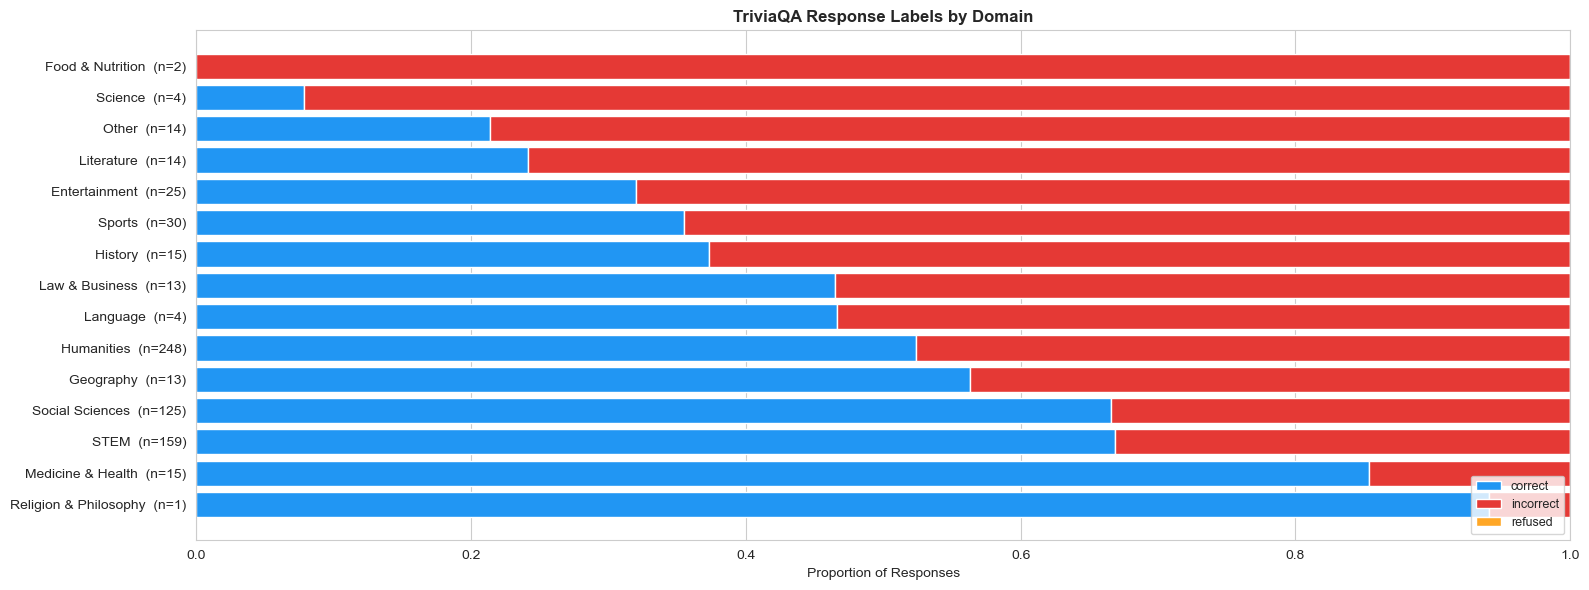

In [8]:
# Stacked bar: canonical domains
fig = plot_response_label_breakdown(
    df,
    domain_col='domain_canonical',
    domain_question_counts=canon_counts,
    title_prefix='TriviaQA Response Labels',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig01_response_label_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()


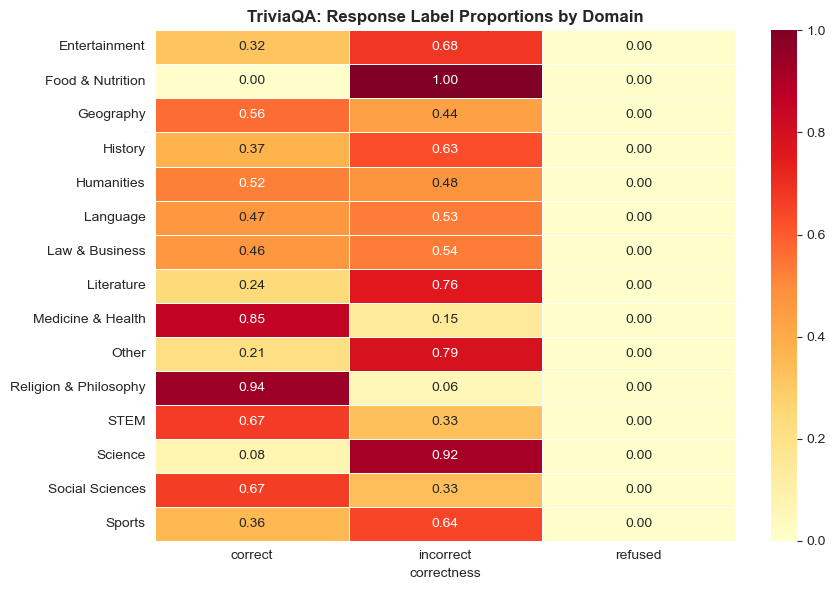

In [9]:
# Heatmap: canonical domains
fig = plot_label_proportion_heatmap(
    df,
    domain_col='domain_canonical',
    title='TriviaQA: Response Label Proportions by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig02_response_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


### Adversarial vs Non-Adversarial

This dataset contains both adversarial and non-adversarial questions.
We check whether the label distribution differs between them.


In [10]:
ct_adv = pd.crosstab(df['adversarial'], df['correctness'])
ct_adv = ct_adv.reindex(columns=[c for c in LABEL_ORDER if c in ct_adv.columns])
print('Response counts by adversarial flag:')
display(ct_adv)
print()
display(ct_adv.div(ct_adv.sum(axis=1), axis=0).round(3))


Response counts by adversarial flag:


correctness,correct,incorrect,refused
adversarial,,,
False,5706,4286,1
True,0,7,0


correctness,correct,incorrect,refused
adversarial,,,
False,0.571,0.429,0.0
True,0.000,1.000,0.0


## Embed All Responses

We embed every response regardless of correctness label. The geometric
features use all 20 embeddings per question.


In [11]:
all_embeddings = embed_responses(
    df,
    model_name='all-MiniLM-L6-v2',
    cache_path=EMBED_CACHE,
    batch_size=256,
)
print(f'Embedding matrix: {all_embeddings.shape}')


Loading cached embeddings from triviaqa_embeddings.npy
Embedding matrix: (10000, 384)


## Feature Extraction

Per question: 5 geometric features from all 20 embeddings, label fractions,
strict hallucination rate (excluding refused from denominator), and binary label.


In [12]:
mu_ref, cov_inv = fit_reference_distribution(all_embeddings, df)


Correct responses for reference: 5706
Reference fitted. mu shape: (384,), precision shape: (384, 384)


In [13]:
feat_df, skipped, skipped_details = extract_question_features(
    df, all_embeddings, mu_ref, cov_inv,
    sim_threshold=SIM_THRESHOLD,
    domain_col='domain_canonical',
)

feat_df.to_csv(os.path.join(OUTPUT_DIR, 'triviaqa_features.csv'), index=False)


  500/500 ...

Questions processed: 500
Questions skipped (all refused): 0
Label distribution:
  Correct (0): 292
  Hallucinated (1): 208
  Rate: 41.6%


### Filtering Diagnostic

In [14]:
canon_raw_counts = questions_per_domain(df, domain_col='domain_canonical')
analysis_domains, excluded_domains = print_filtering_diagnostic(
    feat_df, canon_raw_counts, skipped, MIN_QUESTIONS_FOR_ANALYSIS,
    domain_col='domain_canonical', skipped_details=skipped_details,
)


No questions were skipped.

Surviving questions per domain:
  Humanities                              :  201 /  248  (dropped 47)
  STEM                                    :  129 /  159  (dropped 30)
  Social Sciences                         :   84 /  125  (dropped 41)
  Sports                                  :   17 /   30  (dropped 13)
  Medicine & Health                       :   13 /   15  (dropped 2)
  Entertainment                           :   12 /   25  (dropped 13)
  Law & Business                          :    9 /   13  (dropped 4)  *** BELOW THRESHOLD
  History                                 :    8 /   15  (dropped 7)  *** BELOW THRESHOLD
  Literature                              :    8 /   14  (dropped 6)  *** BELOW THRESHOLD
  Geography                               :    8 /   13  (dropped 5)  *** BELOW THRESHOLD
  Other                                   :    5 /   14  (dropped 9)  *** BELOW THRESHOLD
  Language                                :    3 /    4  (dropped 1)  *

## Question-Level EDA

Per-question label profiles and naive vs strict hallucination rate comparison.


In [15]:
frac_cols = ['frac_correct', 'frac_incorrect', 'frac_refused']
print('Per-question label fraction statistics:')
display(feat_df[frac_cols + ['hall_rate_strict', 'hall_rate_naive']].describe().round(3))


Per-question label fraction statistics:


,frac_correct,frac_incorrect,frac_refused,hall_rate_strict,hall_rate_naive
count,500.000,500.000,500.000,500.000,500.000
mean,0.571,0.429,0.000,0.429,0.429
std,0.421,0.421,0.002,0.421,0.421
min,0.000,0.000,0.000,0.000,0.000
25%,0.050,0.000,0.000,0.000,0.000
50%,0.725,0.275,0.000,0.275,0.275
75%,1.000,0.950,0.000,0.950,0.950
max,1.000,1.000,0.050,1.000,1.000


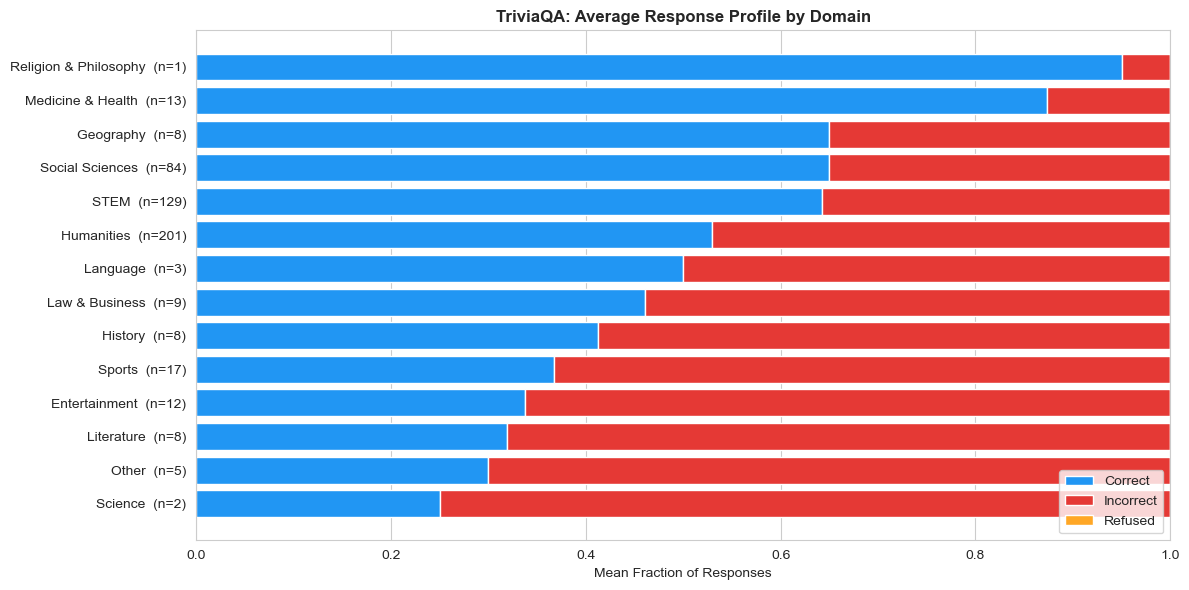

In [16]:
fig = plot_question_label_profiles(
    feat_df,
    frac_cols=['frac_correct', 'frac_incorrect', 'frac_refused'],
    frac_nice_names=['Correct', 'Incorrect', 'Refused'],
    frac_colors=[LABEL_COLORS['correct'], LABEL_COLORS['incorrect'], LABEL_COLORS['refused']],
    domain_col='domain_canonical',
    title='TriviaQA: Average Response Profile by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig04_question_label_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()


### Domain Summary Table

In [17]:
domain_stats = build_domain_stats(
    feat_df,
    strict_rate_col='hall_rate_strict',
    domain_col='domain_canonical',
    extra_mean_cols=['frac_refused'],
    analysis_domains=analysis_domains,
)
display(domain_stats.round(3))
domain_stats.to_csv(os.path.join(OUTPUT_DIR, 'domain_stats.csv'))


,n_questions,n_hallucinated,hall_rate_mean,hall_rate_std,mean_entropy,mean_frac_refused,pct_hallucinated,in_analysis
domain_canonical,,,,,,,,
Science,2,2,0.750,0.283,3.515,0.0,100.0,False
Other,5,4,0.700,0.423,2.735,0.0,80.0,False
Literature,8,6,0.681,0.427,2.360,0.0,75.0,False
Entertainment,12,8,0.662,0.433,1.911,0.0,66.7,True
Sports,17,10,0.632,0.401,1.789,0.0,58.8,True
History,8,4,0.588,0.437,1.573,0.0,50.0,False
Law & Business,9,4,0.539,0.358,1.898,0.0,44.4,False
Language,3,2,0.500,0.328,2.637,0.0,66.7,False
Humanities,201,93,0.470,0.431,1.613,0.0,46.3,True


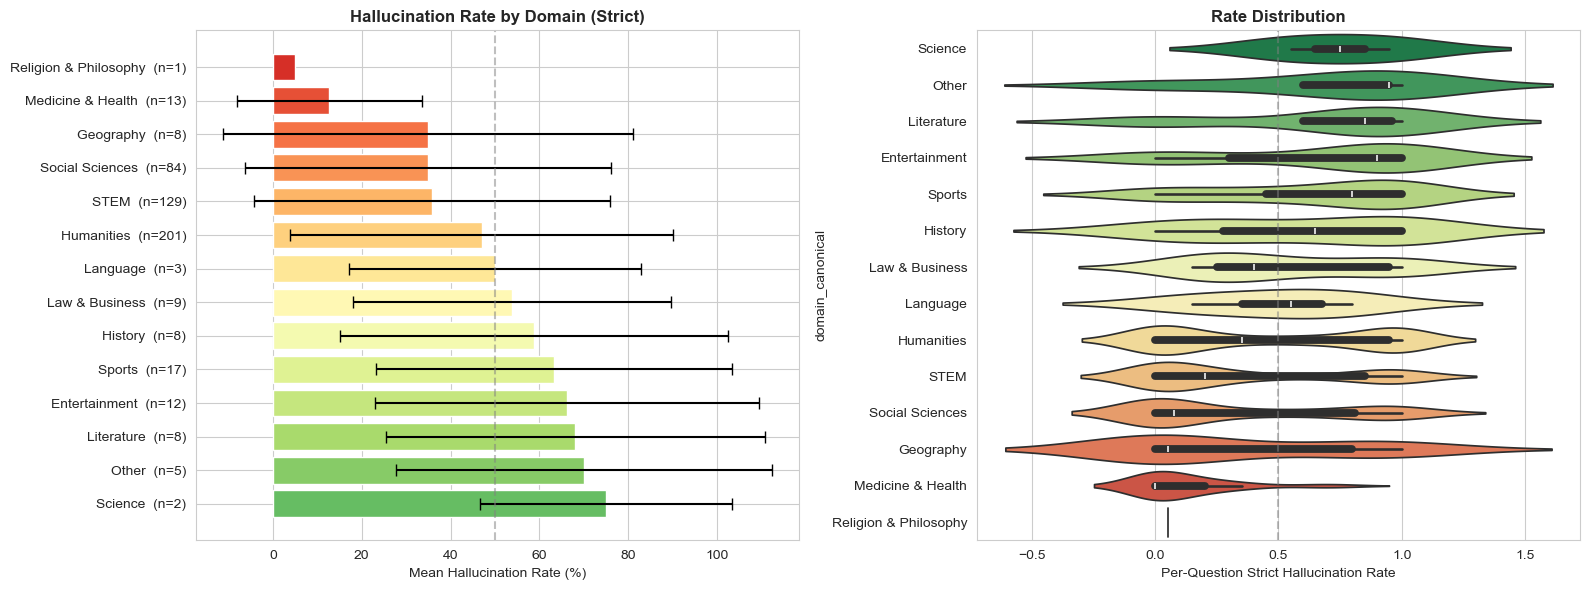

In [18]:
fig = plot_hallucination_rate_by_domain(
    feat_df, domain_stats,
    strict_rate_col='hall_rate_strict',
    domain_col='domain_canonical',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig07_hallu_rate_by_domain.png'), dpi=150, bbox_inches='tight')
plt.show()


## Geometric Feature Distributions

The 5 embedding-geometry features, split by the binary target label.


In [19]:
for lab, tag in [(0, 'Correct'), (1, 'Hallucinated')]:
    sub = feat_df[feat_df['label'] == lab]
    print(f'--- {tag} (n={len(sub)}) ---')
    display(sub[GEO_FEATURES].describe().round(4))


--- Correct (n=292) ---


,H_sem,D_cos,M_bar,K,sig2_S
count,292.0000,292.0000,292.0000,292.0000,292.0000
mean,0.6548,0.0656,17.9410,2.7705,0.0339
std,0.7955,0.0822,4.5720,2.4309,0.0437
min,-0.0000,-0.0000,10.3064,1.0000,0.0000
25%,-0.0000,0.0000,14.9699,1.0000,0.0000
50%,0.2864,0.0305,16.3312,2.0000,0.0109
75%,1.1540,0.1142,20.3769,4.0000,0.0609
max,3.5464,0.3841,37.4261,15.0000,0.1679


--- Hallucinated (n=208) ---


,H_sem,D_cos,M_bar,K,sig2_S
count,208.0000,208.0000,208.0000,208.0000,208.0000
mean,2.6666,0.2839,34.3284,10.0144,0.0576
std,1.1297,0.1272,6.7891,5.2295,0.0332
min,-0.0000,-0.0000,14.5424,1.0000,0.0000
25%,1.8166,0.1904,30.0221,5.0000,0.0335
50%,2.9429,0.3080,33.5949,10.0000,0.0520
75%,3.6219,0.3780,37.9608,14.0000,0.0760
max,4.3219,0.5493,54.6274,20.0000,0.1654


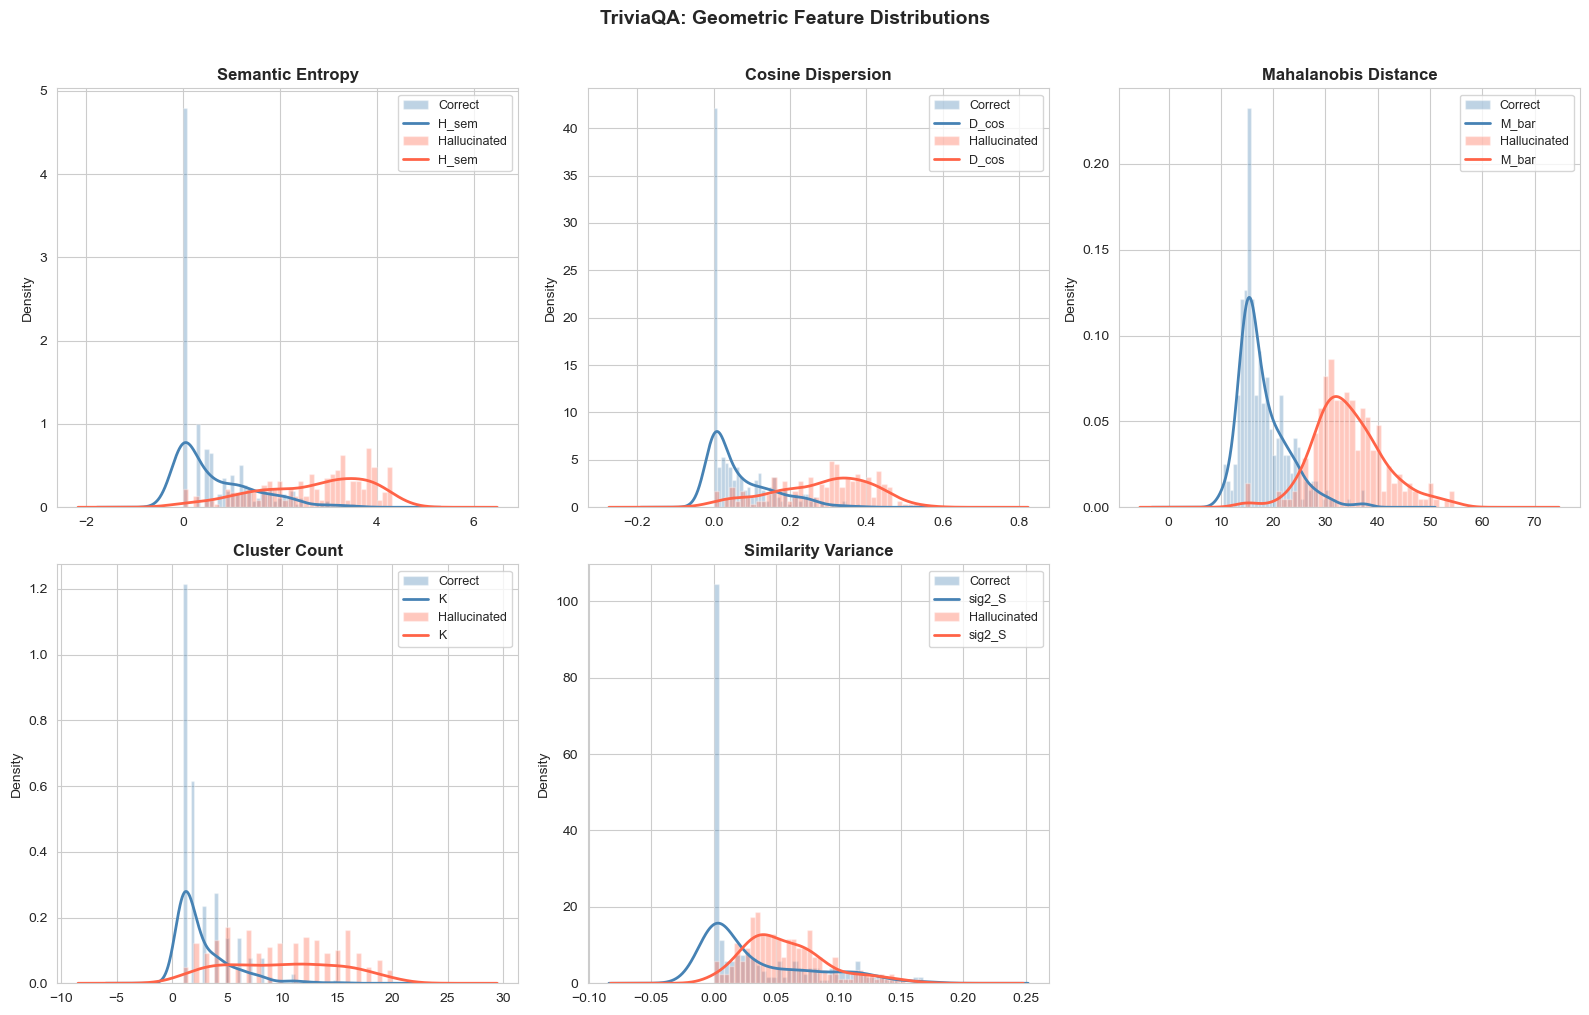

In [20]:
fig = plot_feature_distributions(
    feat_df,
    suptitle='TriviaQA: Geometric Feature Distributions',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig08_feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()


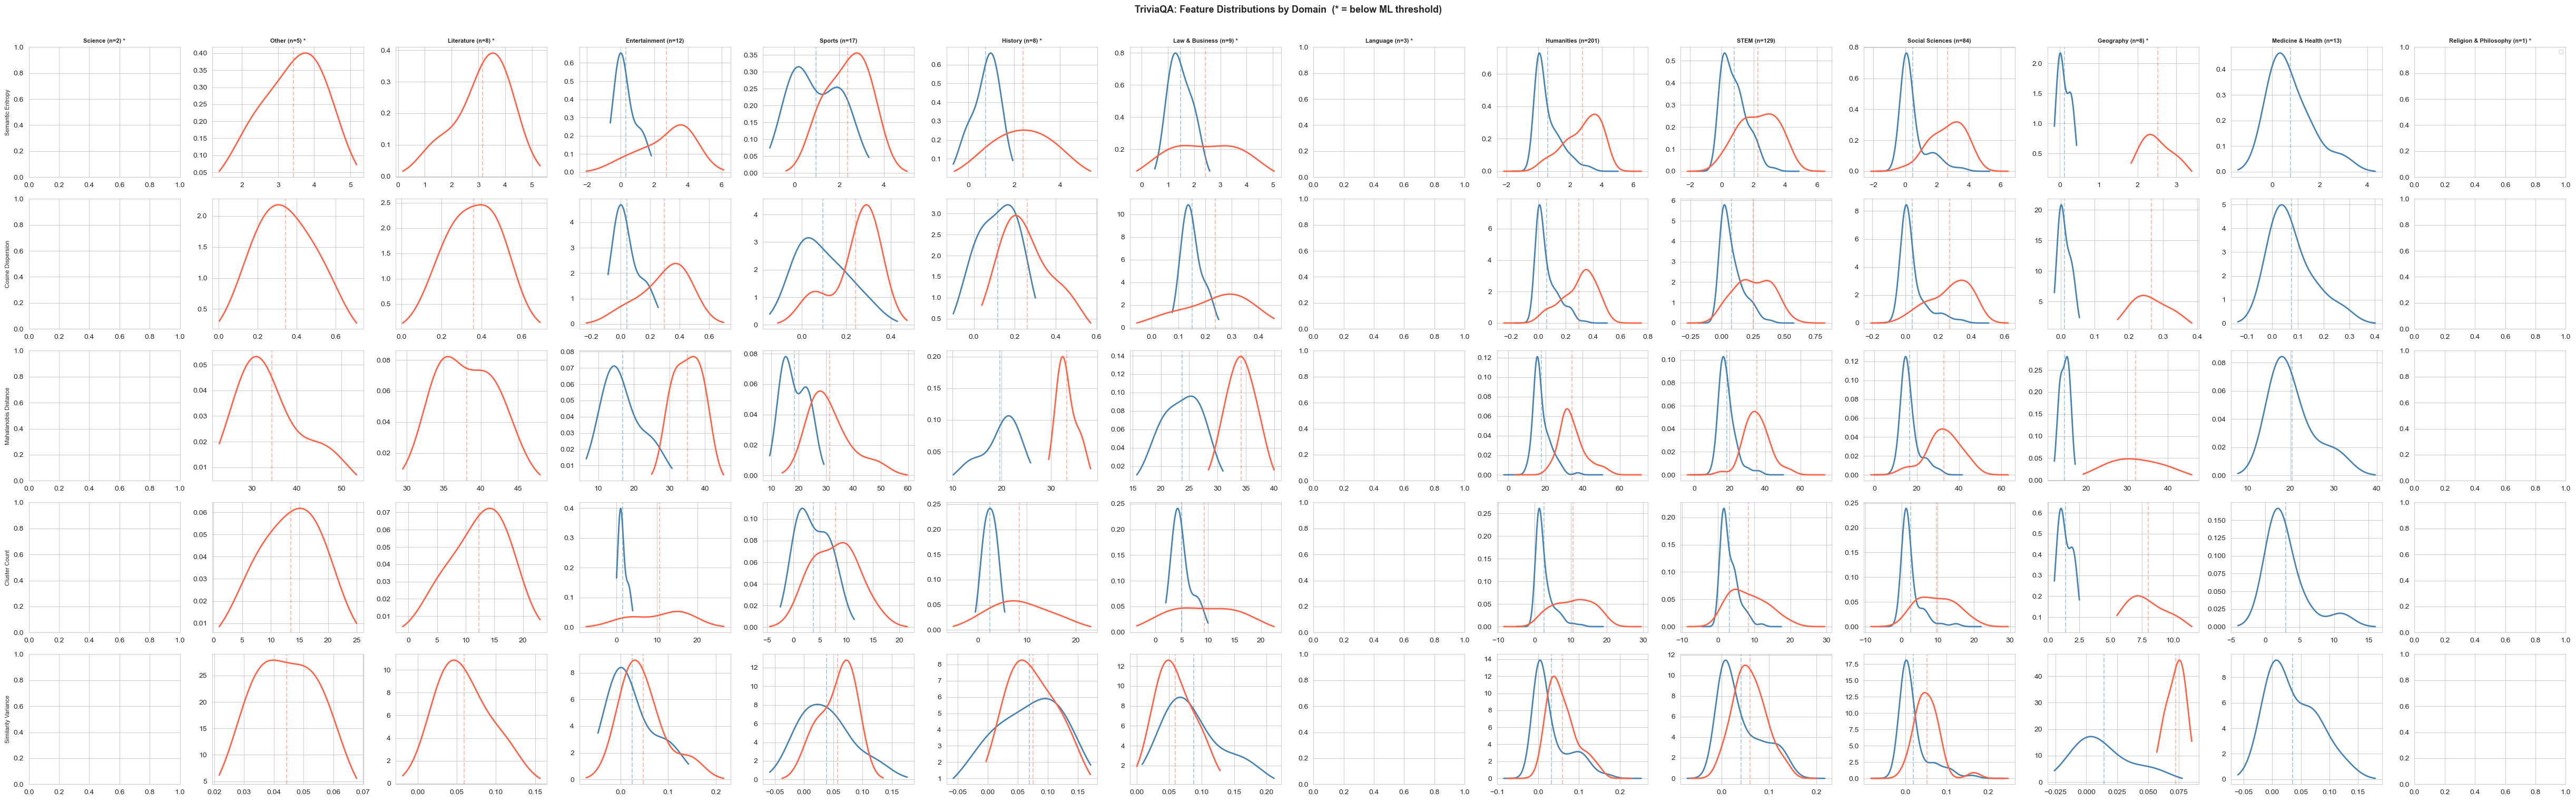

In [21]:
domains_ordered = domain_stats.reset_index()['domain_canonical'].tolist()

fig = plot_per_domain_feature_kdes(
    feat_df,
    domains_ordered=domains_ordered,
    domain_col='domain_canonical',
    analysis_domains=analysis_domains,
    suptitle='TriviaQA: Feature Distributions by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig09_kde_by_domain.png'), dpi=120, bbox_inches='tight')
plt.show()


### Correlation Analysis

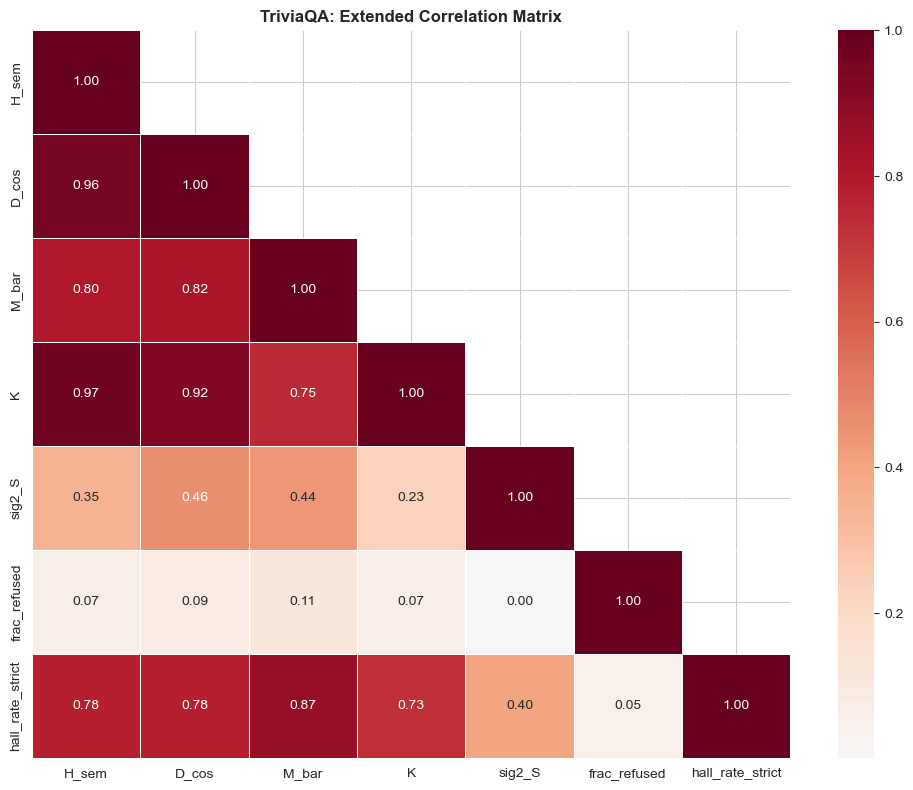

In [22]:
corr_cols = GEO_FEATURES + ['frac_refused', 'hall_rate_strict']
fig = plot_correlation_matrix(
    feat_df, cols=corr_cols,
    title='TriviaQA: Extended Correlation Matrix',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig10_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()


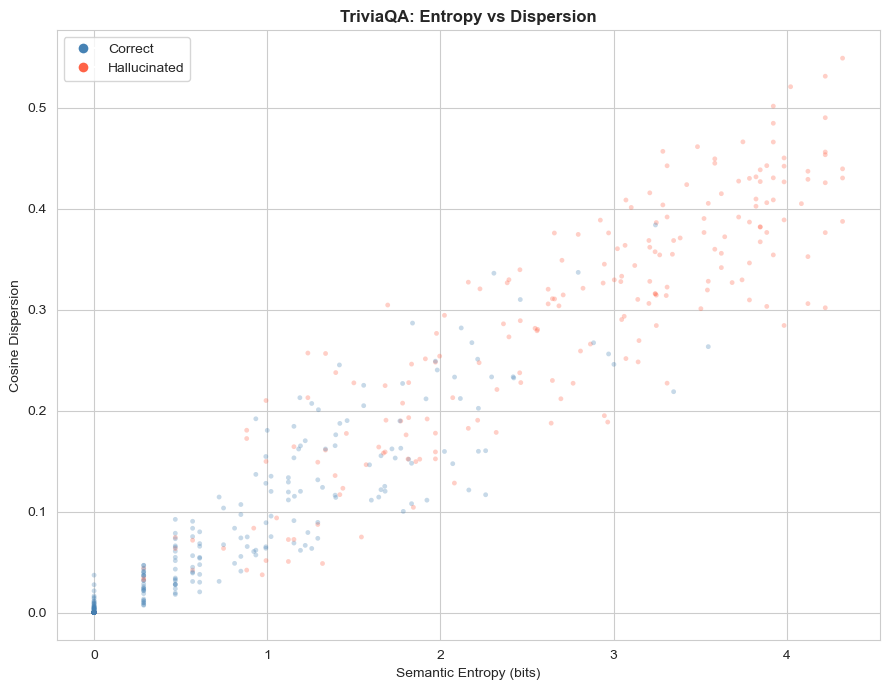

In [23]:
fig = plot_entropy_vs_dispersion(feat_df, title='TriviaQA: Entropy vs Dispersion')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig11_entropy_vs_dispersion.png'), dpi=150, bbox_inches='tight')
plt.show()


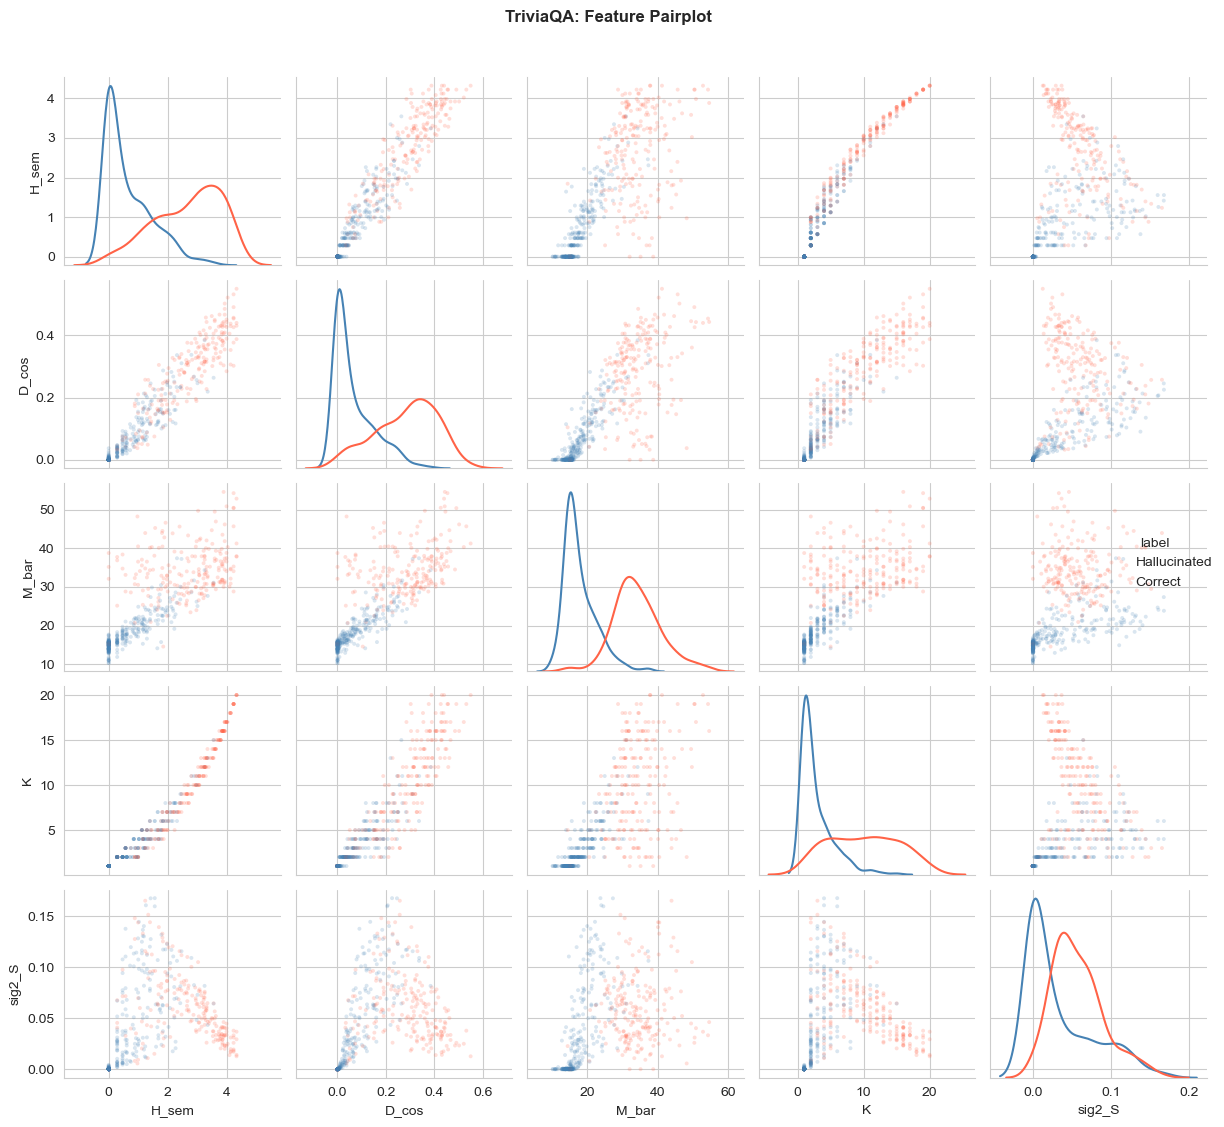

In [24]:
fig = plot_feature_pairplot(feat_df, suptitle='TriviaQA: Feature Pairplot')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig12_pairplot.png'), dpi=100, bbox_inches='tight')
plt.show()


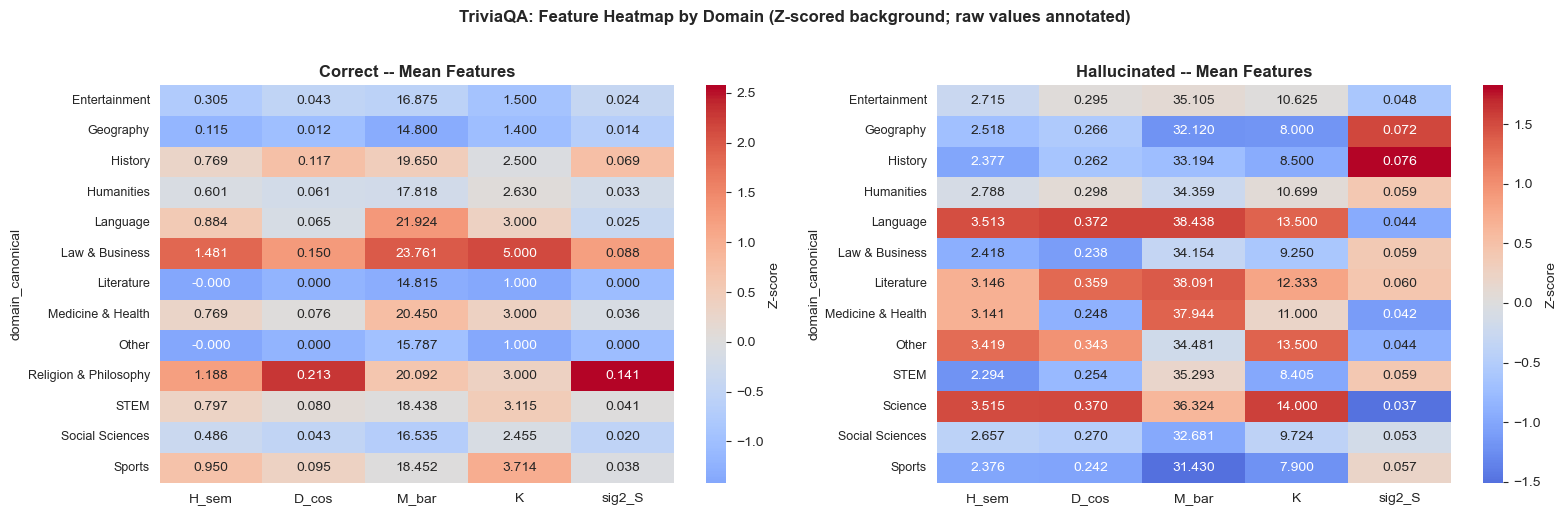

In [25]:
fig = plot_domain_feature_heatmaps(
    feat_df, domain_col='domain_canonical',
    suptitle='TriviaQA: Feature Heatmap by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig13_domain_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()


## Statistical Tests

### KS Tests — Global and Per-Domain


In [26]:
from scipy.stats import ks_2samp

print('Global KS tests (Bonferroni alpha = 0.01):')
ks_global = []
for feat in GEO_FEATURES:
    g0 = feat_df.loc[feat_df['label'] == 0, feat].values
    g1 = feat_df.loc[feat_df['label'] == 1, feat].values
    if len(g0) < 2 or len(g1) < 2:
        continue
    stat, p = ks_2samp(g0, g1)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ks_global.append({'Feature': feat, 'KS_stat': stat, 'p_value': p, 'sig': sig})
    print(f'  {feat:10s}  D={stat:.4f}  p={p:.2e}  {sig}')

pd.DataFrame(ks_global).to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_global.csv'), index=False)


Global KS tests (Bonferroni alpha = 0.01):
  H_sem       D=0.6640  p=2.32e-51  ***
  D_cos       D=0.6811  p=2.66e-54  ***
  M_bar       D=0.8882  p=1.51e-101  ***
  K           D=0.6310  p=5.88e-46  ***
  sig2_S      D=0.4731  p=3.86e-25  ***


In [27]:
all_domains = sorted(feat_df['domain_canonical'].unique())
n_tests = len(GEO_FEATURES) * len(all_domains)
alpha_bonf = 0.05 / n_tests
print(f'Tests: {n_tests}, Bonferroni alpha: {alpha_bonf:.6f}')

ks_rows = []
for dom in all_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    for feat in GEO_FEATURES:
        g0 = df_d[df_d['label'] == 0][feat].values
        g1 = df_d[df_d['label'] == 1][feat].values
        if len(g0) < 2 or len(g1) < 2:
            continue
        stat, p = ks_2samp(g0, g1)
        ks_rows.append({
            'Domain': dom, 'Feature': feat,
            'KS_stat': round(stat, 4), 'p_value': p,
            'Significant': p < alpha_bonf,
            'n_questions': len(df_d),
        })

df_ks = pd.DataFrame(ks_rows)
df_ks.to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_per_domain.csv'), index=False)
display(df_ks)


Tests: 70, Bonferroni alpha: 0.000714


,Domain,Feature,KS_stat,p_value,Significant,n_questions
0,Entertainment,H_sem,0.8750,2.020202e-02,False,12
1,Entertainment,D_cos,0.7500,8.484848e-02,False,12
2,Entertainment,M_bar,1.0000,4.040404e-03,False,12
3,Entertainment,K,0.8750,2.020202e-02,False,12
4,Entertainment,sig2_S,0.6250,2.222222e-01,False,12
5,Geography,H_sem,1.0000,3.571429e-02,False,8
6,Geography,D_cos,1.0000,3.571429e-02,False,8
7,Geography,M_bar,1.0000,3.571429e-02,False,8
8,Geography,K,1.0000,3.571429e-02,False,8
9,Geography,sig2_S,1.0000,3.571429e-02,False,8


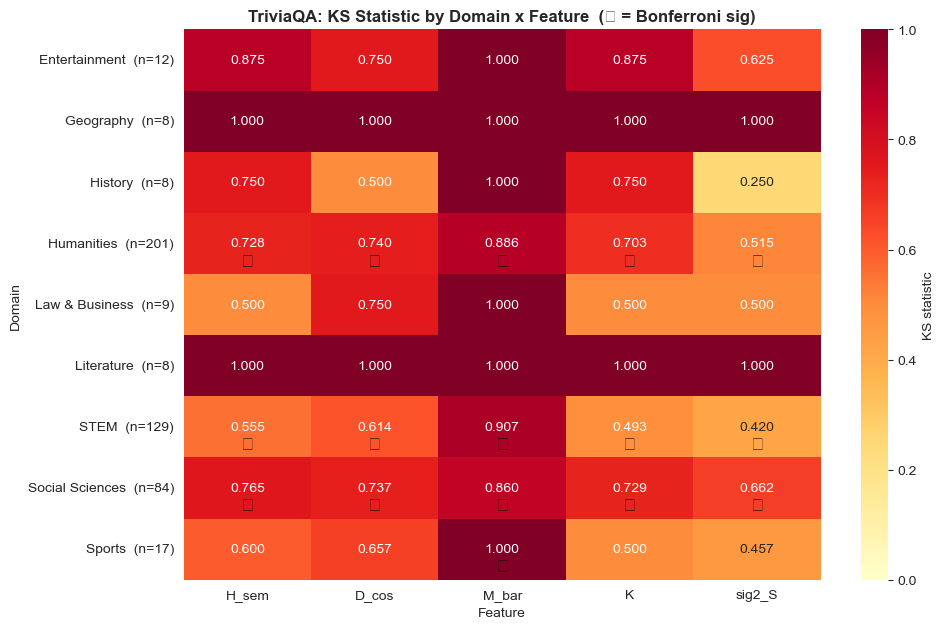

In [28]:
survived_counts = feat_df['domain_canonical'].value_counts()
fig = plot_ks_heatmap(
    df_ks, survived_counts=survived_counts,
    title='TriviaQA: KS Statistic by Domain x Feature',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig14_ks_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


### Permutation Test on Entropy Difference

Observed delta (hallu - correct): 2.0118 bits
Permutation p-value (10000 iters): 0.000000


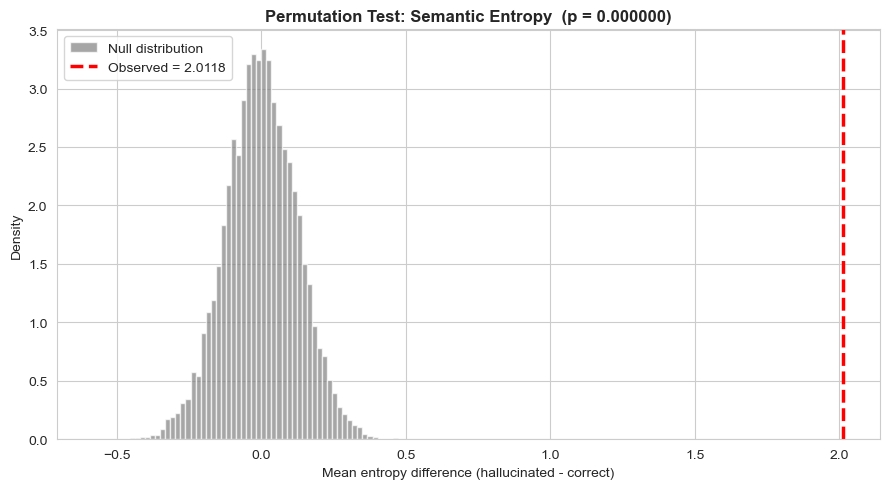

In [29]:
ent_correct = feat_df.loc[feat_df['label'] == 0, 'H_sem'].values
ent_hallu   = feat_df.loc[feat_df['label'] == 1, 'H_sem'].values
delta_obs   = ent_hallu.mean() - ent_correct.mean()
print(f'Observed delta (hallu - correct): {delta_obs:.4f} bits')

all_ent    = feat_df['H_sem'].values
all_labels = feat_df['label'].values
rng = np.random.default_rng(RANDOM_SEED)

perm_deltas = np.zeros(N_PERMUTATIONS)
for p in range(N_PERMUTATIONS):
    shuffled = rng.permutation(all_labels)
    perm_deltas[p] = all_ent[shuffled == 1].mean() - all_ent[shuffled == 0].mean()

perm_pval = (perm_deltas >= delta_obs).sum() / N_PERMUTATIONS
print(f'Permutation p-value ({N_PERMUTATIONS} iters): {perm_pval:.6f}')

fig = plot_permutation_test(perm_deltas, delta_obs, N_PERMUTATIONS, perm_pval)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig15_permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()


## Classification and Ablation

Feature subsets × classifiers using 5-fold stratified CV.


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from collections import Counter
import xgboost as xgb

EXTENDED_FEATURES = GEO_FEATURES + ['frac_refused']

X_geo = feat_df[GEO_FEATURES].values
X_ext = feat_df[EXTENDED_FEATURES].values
y_all = feat_df['label'].values

scaler_geo = StandardScaler()
scaler_ext = StandardScaler()
X_geo_sc = scaler_geo.fit_transform(X_geo)
X_ext_sc = scaler_ext.fit_transform(X_ext)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0,
    ),
}

ablation_sets = {
    'Entropy only (H_sem)':        ('geo', [0]),
    'Geometry only (D_cos, M_bar)': ('geo', [1, 2]),
    'Entropy + Geometry':           ('geo', [0, 1, 2]),
    'All 5 geometric':              ('geo', [0, 1, 2, 3, 4]),
    'All 5 + refused':              ('ext', list(range(len(EXTENDED_FEATURES)))),
}

clf_rows = []
for variant, (fset, feat_idx) in ablation_sets.items():
    X_use = X_geo_sc if fset == 'geo' else X_ext_sc
    X_sub = X_use[:, feat_idx]
    for clf_name, clf in classifiers.items():
        scores = cross_val_score(clf, X_sub, y_all, cv=cv, scoring='roc_auc')
        clf_rows.append({
            'Variant': variant, 'Classifier': clf_name,
            'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
        })
        print(f'  {variant:35s} | {clf_name:22s} | AUC = {scores.mean():.4f} +/- {scores.std():.4f}')

df_clf = pd.DataFrame(clf_rows)
df_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_results.csv'), index=False)
print()
display(df_clf.pivot_table(index='Variant', columns='Classifier', values='AUC_mean').round(3))


  Entropy only (H_sem)                | Logistic Regression    | AUC = 0.9100 +/- 0.0288
  Entropy only (H_sem)                | Random Forest          | AUC = 0.8979 +/- 0.0336
  Entropy only (H_sem)                | XGBoost                | AUC = 0.8979 +/- 0.0258
  Geometry only (D_cos, M_bar)        | Logistic Regression    | AUC = 0.9717 +/- 0.0105
  Geometry only (D_cos, M_bar)        | Random Forest          | AUC = 0.9683 +/- 0.0098
  Geometry only (D_cos, M_bar)        | XGBoost                | AUC = 0.9648 +/- 0.0123
  Entropy + Geometry                  | Logistic Regression    | AUC = 0.9722 +/- 0.0102
  Entropy + Geometry                  | Random Forest          | AUC = 0.9690 +/- 0.0099
  Entropy + Geometry                  | XGBoost                | AUC = 0.9591 +/- 0.0165
  All 5 geometric                     | Logistic Regression    | AUC = 0.9736 +/- 0.0097
  All 5 geometric                     | Random Forest          | AUC = 0.9699 +/- 0.0120
  All 5 geometric    

Classifier,Logistic Regression,Random Forest,XGBoost
Variant,,,
All 5 + refused,0.974,0.969,0.969
All 5 geometric,0.974,0.970,0.969
Entropy + Geometry,0.972,0.969,0.959
Entropy only (H_sem),0.910,0.898,0.898
"Geometry only (D_cos, M_bar)",0.972,0.968,0.965


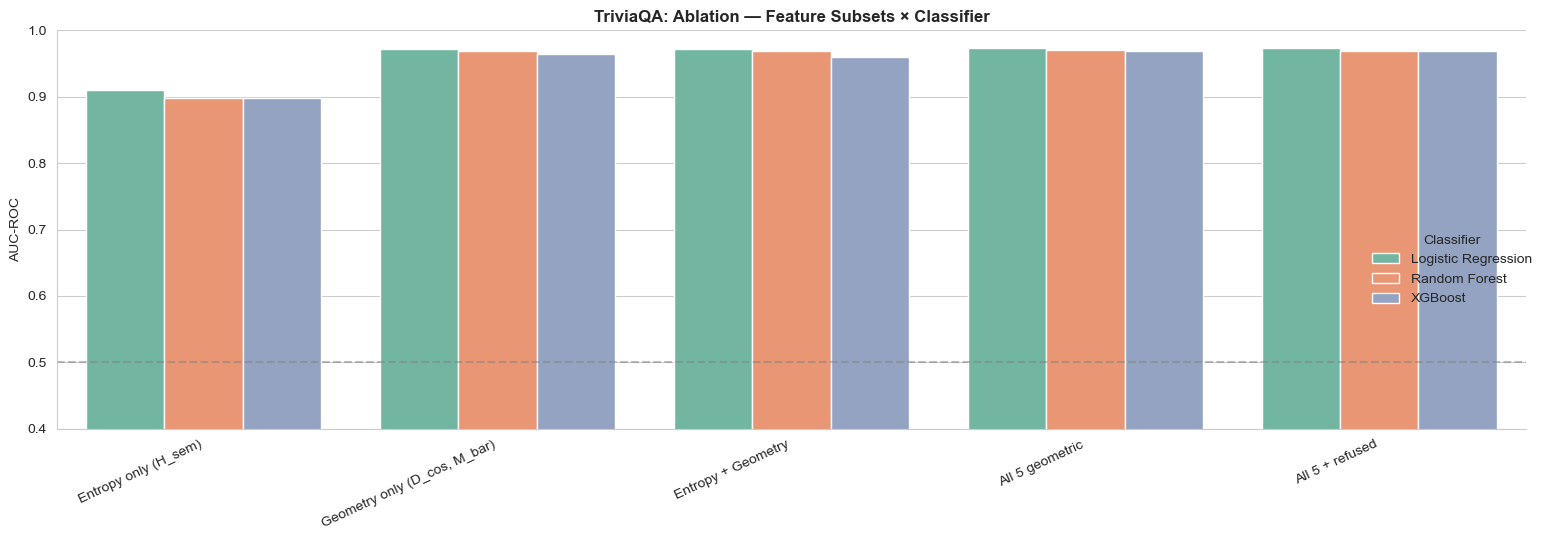

In [31]:
g = sns.catplot(
    data=df_clf, kind='bar',
    x='Variant', y='AUC_mean', hue='Classifier',
    palette='Set2', height=5.5, aspect=2.5,
    capsize=0.05, errwidth=1.5,
)
g.ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
g.ax.set_ylim(0.4, 1.0)
g.ax.set_title('TriviaQA: Ablation — Feature Subsets × Classifier', fontweight='bold')
g.ax.set_ylabel('AUC-ROC')
g.ax.set_xlabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig16_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()


### Per-Domain Classification

In [32]:
domain_clf_rows = []

for dom in analysis_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    X_d = df_d[GEO_FEATURES].values
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        print(f'  Skipping {dom} (single class)')
        continue
    X_d_sc = StandardScaler().fit_transform(X_d)
    for clf_name, clf in classifiers.items():
        n_folds = min(5, min(Counter(y_d).values()))
        if n_folds < 2:
            continue
        cv_d = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
        scores = cross_val_score(clf, X_d_sc, y_d, cv=cv_d, scoring='roc_auc')
        domain_clf_rows.append({
            'Domain': dom, 'Classifier': clf_name,
            'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
            'n_questions': len(df_d),
        })

if excluded_domains:
    print(f'Excluded (< {MIN_QUESTIONS_FOR_ANALYSIS} questions): {excluded_domains}')

df_dom_clf = pd.DataFrame(domain_clf_rows)
df_dom_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_per_domain.csv'), index=False)
display(df_dom_clf.pivot_table(index='Domain', columns='Classifier', values='AUC_mean').round(3))


Excluded (< 10 questions): ['Geography', 'History', 'Language', 'Law & Business', 'Literature', 'Other', 'Religion & Philosophy', 'Science']


Classifier,Logistic Regression,Random Forest,XGBoost
Domain,,,
Entertainment,0.875,0.875,0.500
Humanities,0.978,0.973,0.972
STEM,0.975,0.954,0.954
Social Sciences,0.961,0.920,0.941
Sports,0.850,0.900,0.850


### Bootstrap AUC Confidence Intervals

In [33]:
rng_boot = np.random.default_rng(RANDOM_SEED)

print('Global bootstrap (RF, 5 geometric features):')
auc_boot_global = []
for _ in range(N_BOOTSTRAP):
    idx = rng_boot.choice(len(y_all), len(y_all), replace=True)
    oob = np.setdiff1d(np.arange(len(y_all)), idx)
    if len(oob) < 10 or len(np.unique(y_all[oob])) < 2:
        continue
    if len(np.unique(y_all[idx])) < 2:
        continue
    rf_b = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=0)
    rf_b.fit(X_geo_sc[idx], y_all[idx])
    proba = rf_b.predict_proba(X_geo_sc[oob])[:, 1]
    auc_boot_global.append(roc_auc_score(y_all[oob], proba))

auc_boot_global = np.array(auc_boot_global)
ci_lo, ci_hi = np.percentile(auc_boot_global, [2.5, 97.5])
print(f'  AUC = {auc_boot_global.mean():.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')


Global bootstrap (RF, 5 geometric features):
  AUC = 0.9715  95% CI [0.9494, 0.9891]


In [34]:
boot_rows = []
print('Per-domain bootstrap:')
for dom in analysis_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        continue
    auc_list = []
    for _ in range(N_BOOTSTRAP):
        idx = rng_boot.choice(len(y_d), len(y_d), replace=True)
        oob = np.setdiff1d(np.arange(len(y_d)), idx)
        if len(oob) < 5 or len(np.unique(y_d[oob])) < 2:
            continue
        if len(np.unique(y_d[idx])) < 2:
            continue
        rf_b = RandomForestClassifier(n_estimators=50, random_state=0)
        rf_b.fit(X_d[idx], y_d[idx])
        proba = rf_b.predict_proba(X_d[oob])[:, 1]
        auc_list.append(roc_auc_score(y_d[oob], proba))
    if len(auc_list) < 10:
        continue
    arr = np.array(auc_list)
    lo, hi = np.percentile(arr, [2.5, 97.5])
    boot_rows.append({
        'Domain': dom, 'AUC_mean': arr.mean(),
        'CI_low': lo, 'CI_high': hi, 'n_questions': len(df_d),
    })
    print(f'  {dom:30s}  AUC={arr.mean():.3f}  [{lo:.3f}, {hi:.3f}]  (n={len(df_d)})')

if excluded_domains:
    print(f'\nExcluded: {excluded_domains}')

df_boot = pd.DataFrame(boot_rows).sort_values('AUC_mean', ascending=True)
df_boot.to_csv(os.path.join(OUTPUT_DIR, 'bootstrap_auc.csv'), index=False)


Per-domain bootstrap:
  Entertainment                   AUC=0.928  [0.590, 1.000]  (n=12)
  Humanities                      AUC=0.969  [0.932, 0.994]  (n=201)
  STEM                            AUC=0.945  [0.882, 0.999]  (n=129)
  Social Sciences                 AUC=0.923  [0.833, 0.996]  (n=84)
  Sports                          AUC=0.920  [0.500, 1.000]  (n=17)

Excluded: ['Geography', 'History', 'Language', 'Law & Business', 'Literature', 'Other', 'Religion & Philosophy', 'Science']


### ROC Curves

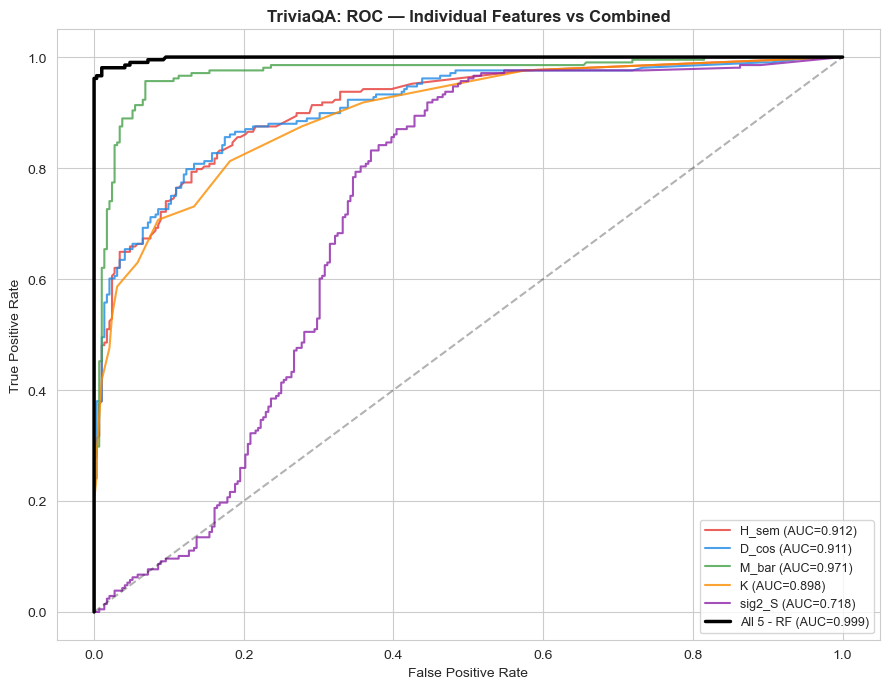

In [35]:
fig, ax = plt.subplots(figsize=(9, 7))
feat_colors = ['#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA']

for i, (feat, color) in enumerate(zip(GEO_FEATURES, feat_colors)):
    vals = X_geo_sc[:, i]
    fpr, tpr, _ = roc_curve(y_all, vals)
    auc_s = roc_auc_score(y_all, vals)
    ax.plot(fpr, tpr, color=color, linewidth=1.5, alpha=0.8,
            label=f'{feat} (AUC={auc_s:.3f})')

rf_full = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED)
rf_full.fit(X_geo_sc, y_all)
y_scores = rf_full.predict_proba(X_geo_sc)[:, 1]
fpr_a, tpr_a, _ = roc_curve(y_all, y_scores)
auc_a = roc_auc_score(y_all, y_scores)
ax.plot(fpr_a, tpr_a, color='black', linewidth=2.5,
        label=f'All 5 - RF (AUC={auc_a:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('TriviaQA: ROC — Individual Features vs Combined', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig17_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


## Feature Importance and SHAP

XGBoost GAIN per domain + SHAP beeswarm plots (analysis domains only).


In [36]:
import shap

xgb_imp = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0,
)

importance_data = {}
for dom in analysis_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        importance_data[dom] = np.zeros(5)
        continue
    xgb_imp.fit(X_d, y_d)
    booster = xgb_imp.get_booster()
    gain_dict = booster.get_score(importance_type='gain')
    gains = np.array([gain_dict.get(f'f{i}', 0.0) for i in range(5)], dtype=float)
    total = gains.sum()
    importance_data[dom] = gains / total if total > 0 else gains

df_imp = pd.DataFrame(importance_data, index=GEO_FEATURES).T
print('Normalized GAIN importance per domain:')
display(df_imp.round(3))


Normalized GAIN importance per domain:


,H_sem,D_cos,M_bar,K,sig2_S
Entertainment,0.245,0.048,0.291,0.394,0.022
Humanities,0.070,0.190,0.609,0.036,0.095
Medicine & Health,0.000,0.000,0.000,0.000,0.000
STEM,0.112,0.139,0.602,0.074,0.073
Social Sciences,0.237,0.091,0.517,0.062,0.093
Sports,0.284,0.153,0.550,0.000,0.013


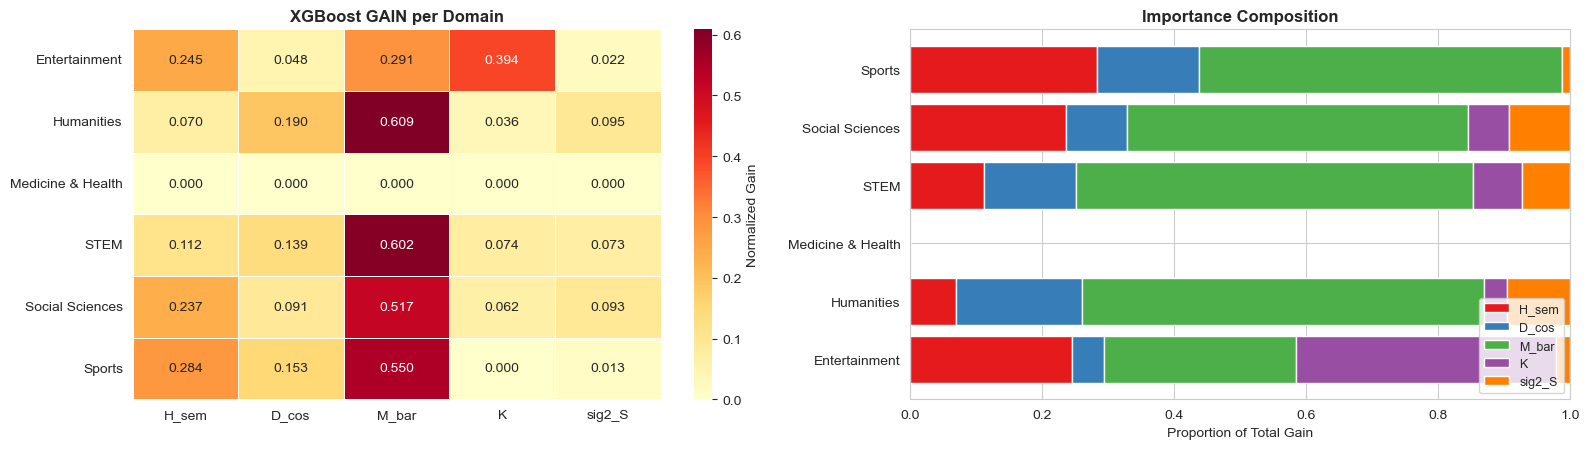

In [37]:
feat_colors_list = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(analysis_domains) * 0.6 + 1)))

sns.heatmap(df_imp, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=df_imp.values.max(),
            ax=axes[0], linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Normalized Gain'})
axes[0].set_title('XGBoost GAIN per Domain', fontweight='bold')

bottoms = np.zeros(len(df_imp))
for feat, color in zip(GEO_FEATURES, feat_colors_list):
    vals = df_imp[feat].values
    axes[1].barh(df_imp.index, vals, left=bottoms, color=color, label=feat)
    bottoms += vals
axes[1].set_xlabel('Proportion of Total Gain')
axes[1].set_title('Importance Composition', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig18_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()


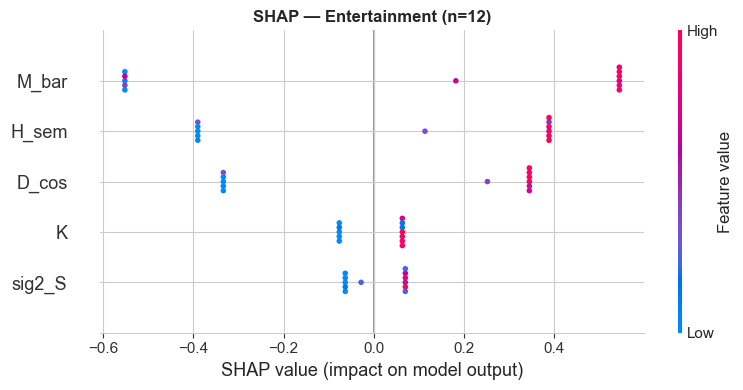

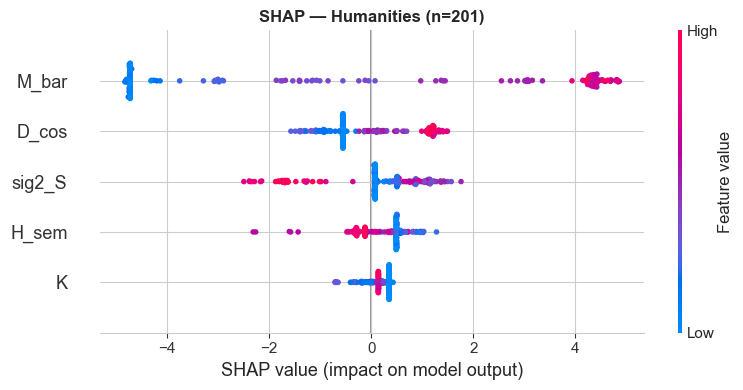

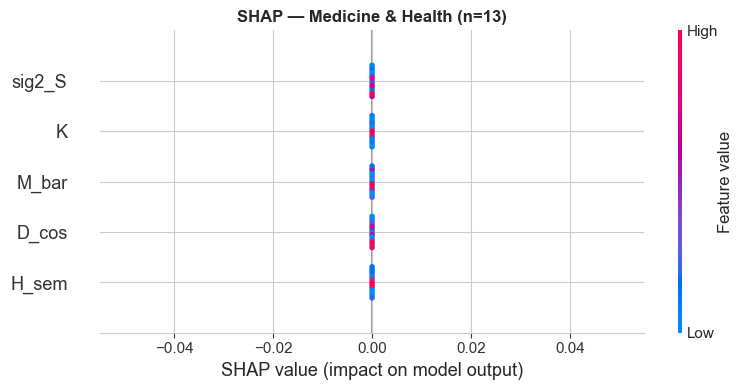

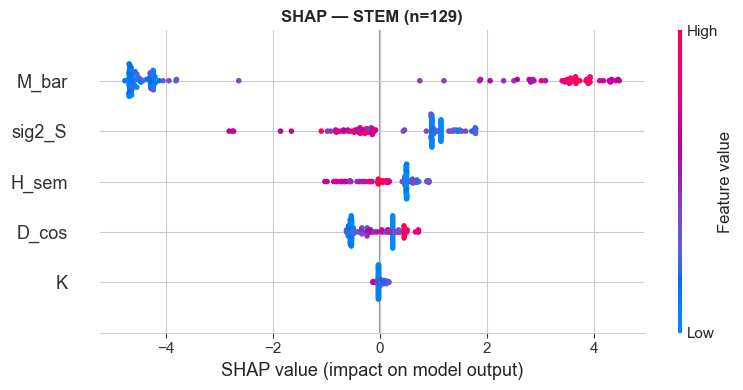

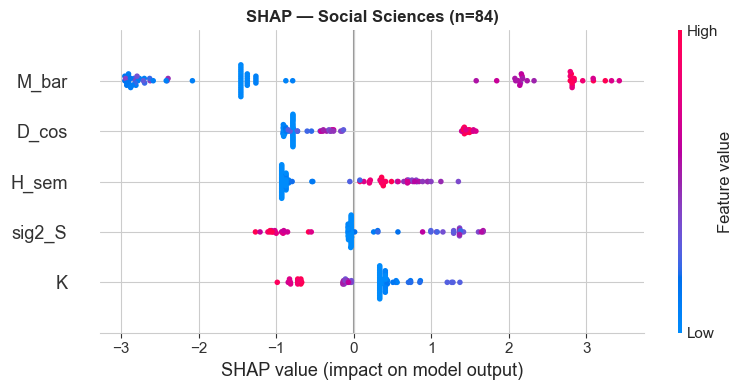

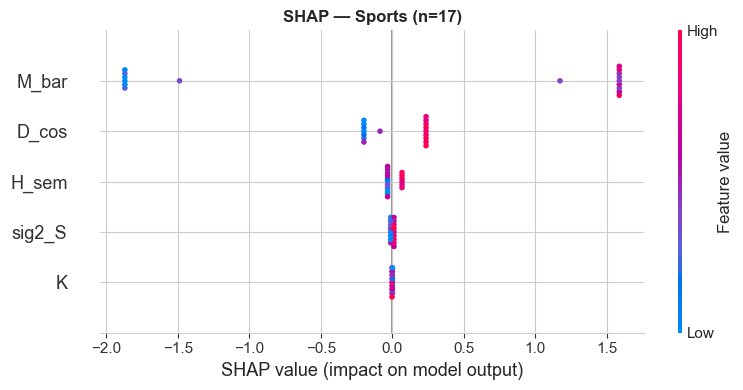

Excluded from per-domain SHAP: ['Geography', 'History', 'Language', 'Law & Business', 'Literature', 'Other', 'Religion & Philosophy', 'Science']


In [38]:
xgb_shap = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0,
)

for dom in analysis_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        print(f'Skipping {dom}')
        continue
    xgb_shap.fit(X_d, y_d)
    explainer = shap.TreeExplainer(xgb_shap)
    sv = explainer.shap_values(X_d)
    if isinstance(sv, list):
        sv = sv[1]
    plt.figure(figsize=(8, 4))
    shap.summary_plot(sv, X_d, feature_names=GEO_FEATURES, show=False, plot_size=None)
    plt.title(f'SHAP — {dom} (n={len(df_d)})', fontweight='bold')
    plt.tight_layout()
    plt.show()

if excluded_domains:
    print(f'Excluded from per-domain SHAP: {excluded_domains}')


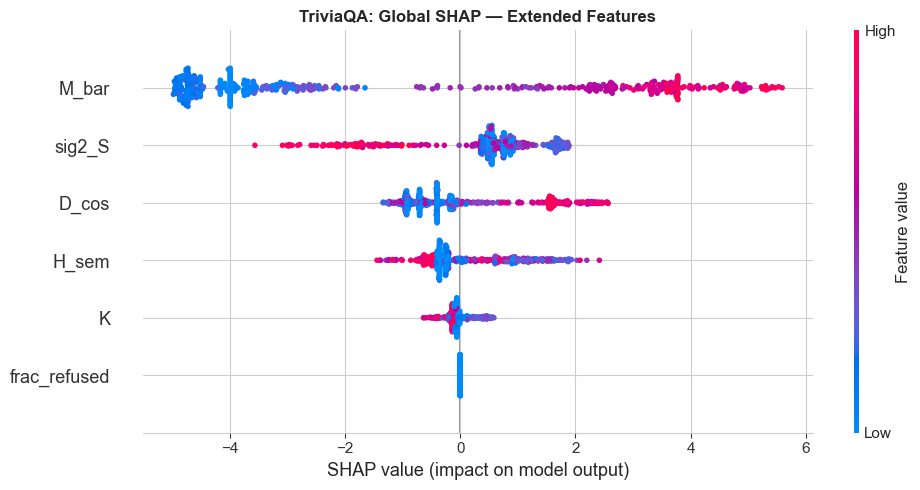

In [39]:
# Global SHAP on extended features
xgb_shap.fit(X_ext_sc, y_all)
explainer = shap.TreeExplainer(xgb_shap)
sv_global = explainer.shap_values(X_ext_sc)
if isinstance(sv_global, list):
    sv_global = sv_global[1]

plt.figure(figsize=(10, 5))
shap.summary_plot(sv_global, X_ext_sc, feature_names=EXTENDED_FEATURES,
                  show=False, plot_size=None)
plt.title('TriviaQA: Global SHAP — Extended Features', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig19_shap_global.png'), dpi=150, bbox_inches='tight')
plt.show()


## UMAP 


Running UMAP on 8000 points...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


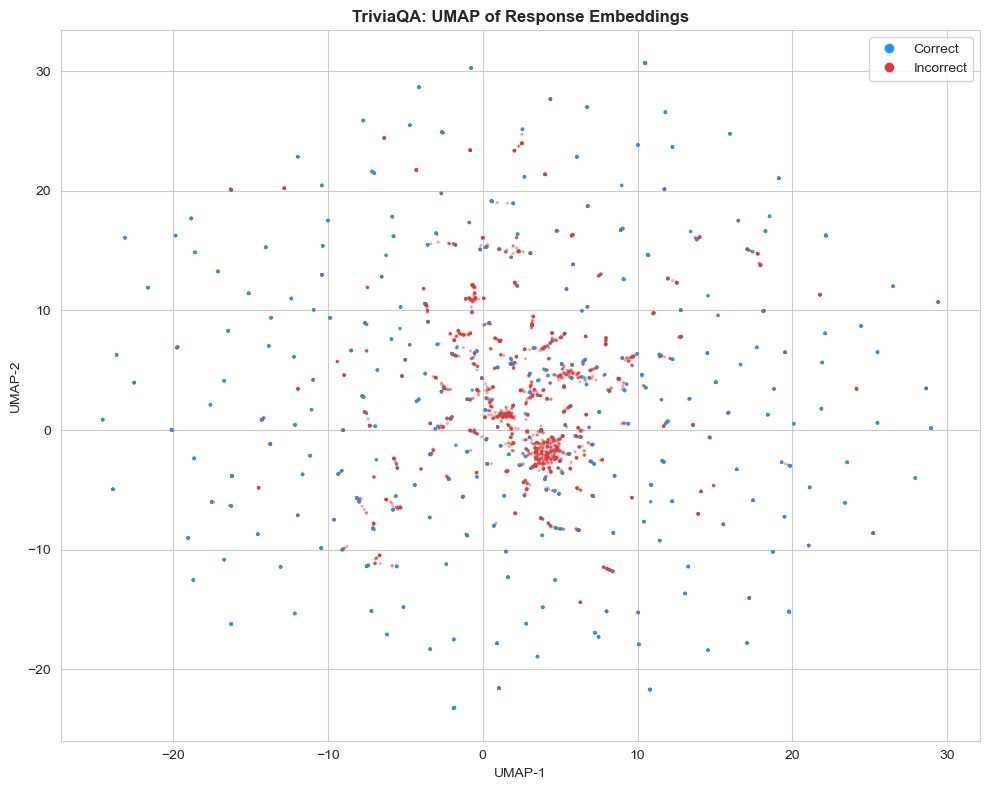

In [40]:
try:
    import umap

    max_pts = 8000
    rng_u = np.random.default_rng(RANDOM_SEED)
    if all_embeddings.shape[0] > max_pts:
        idx_sub = rng_u.choice(all_embeddings.shape[0], max_pts, replace=False)
    else:
        idx_sub = np.arange(all_embeddings.shape[0])

    emb_sub = all_embeddings[idx_sub]
    lab_sub = df['correctness'].values[idx_sub]

    print(f'Running UMAP on {len(idx_sub)} points...')
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED)
    proj = reducer.fit_transform(emb_sub)

    fig = plot_umap(proj, lab_sub, title='TriviaQA: UMAP of Response Embeddings')
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig20_umap.png'), dpi=120, bbox_inches='tight')
    plt.show()

except ImportError:
    print('umap-learn not installed, skipping UMAP.')


## Summary

In [41]:
print('=' * 70)
print('TRIVIAQA HALLUCINATION DETECTION — RESULTS SUMMARY')
print('=' * 70)
print(f'  Dataset: TriviaQA')
print(f'  Total questions (raw): {df["prompt_id"].nunique()}')
print(f'  Questions analyzed: {len(feat_df)}')
print(f'  Questions skipped (all refused): {skipped}')
print(f'  Samples per question: 20')
print(f'  Canonical domains: {len(all_domains)}')
print(f'  Domains in ML (>= {MIN_QUESTIONS_FOR_ANALYSIS}): {len(analysis_domains)}')
if excluded_domains:
    print(f'  Excluded from ML: {excluded_domains}')
print()

resp_counts = df['correctness'].value_counts()
print('  Response-level breakdown:')
for lab in LABEL_ORDER:
    if lab in resp_counts.index:
        pct = resp_counts[lab] / len(df) * 100
        print(f'    {lab:12s}: {resp_counts[lab]:6d}  ({pct:.1f}%)')
print()

print(f'  Binary label (strict):')
print(f'    Correct: {(feat_df["label"]==0).sum()}, Hallucinated: {(feat_df["label"]==1).sum()}')
print(f'    Rate: {feat_df["label"].mean()*100:.1f}%')
print()

print(f'  Permutation test (entropy):')
print(f'    delta = {delta_obs:.4f} bits, p = {perm_pval:.6f}')
print()

print(f'  Bootstrap AUC (RF, 5 geometric features):')
print(f'    AUC = {auc_boot_global.mean():.4f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
print()

best = df_clf.loc[df_clf['AUC_mean'].idxmax()]
print(f'  Best classifier config:')
print(f'    {best["Classifier"]} / {best["Variant"]} — AUC={best["AUC_mean"]:.4f}')
print()

print(f'  Top feature by domain (XGBoost GAIN):')
for dom, row in df_imp.iterrows():
    top = row.idxmax()
    print(f'    {dom:30s}: {top} ({row[top]:.3f})')
print()
print(f'  Outputs: {OUTPUT_DIR}/')
print('=' * 70)


TRIVIAQA HALLUCINATION DETECTION — RESULTS SUMMARY
  Dataset: TriviaQA
  Total questions (raw): 500
  Questions analyzed: 500
  Questions skipped (all refused): 0
  Samples per question: 20
  Canonical domains: 14
  Domains in ML (>= 10): 6
  Excluded from ML: ['Geography', 'History', 'Language', 'Law & Business', 'Literature', 'Other', 'Religion & Philosophy', 'Science']

  Response-level breakdown:
    correct     :   5706  (57.1%)
    incorrect   :   4293  (42.9%)
    refused     :      1  (0.0%)

  Binary label (strict):
    Correct: 292, Hallucinated: 208
    Rate: 41.6%

  Permutation test (entropy):
    delta = 2.0118 bits, p = 0.000000

  Bootstrap AUC (RF, 5 geometric features):
    AUC = 0.9715, 95% CI [0.9494, 0.9891]

  Best classifier config:
    Logistic Regression / All 5 + refused — AUC=0.9736

  Top feature by domain (XGBoost GAIN):
    Entertainment                 : K (0.394)
    Humanities                    : M_bar (0.609)
    Medicine & Health             : H_sem 